# MNIST Pipeline — kompletan PyTorch eksperiment

Ovaj notebook je **minimalni primer kompletnog trening pipeline-a** koji prati strukturu opisanu u uvodu kursa.  
Svaki korak ima jasnu ulogu — nije magija, već konkretan deo eksperimenta.

**Šta ćemo proći:**
1. Dataset — učitavanje, vizualizacija, podela na train/val/test
2. Baseline — šta bi postigao trivijalni model?
3. MLP bez regularizacije — demonstracija overfitting-a
4. MLP sa regularizacijom — dropout + weight decay
5. CNN — konvoluciona mreža kao prirodniji pristup za slike
6. Checkpointing — čuvanje i učitavanje najboljeg modela
7. Evaluacija na test skupu — accuracy, matrica konfuzije, izveštaj po klasama
8. Analiza grešaka — konkretni primeri na kojima model greši
9. Finalno poređenje — accuracy, vreme treninga i veličina sva tri modela

> **Napomena za studente:** Kod za vaš projekat će koristiti isti obrazac.  
> Promeniti ćete: dataset, arhitekturu, loss funkciju i metrike.  
> Petlja, checkpointing i analiza grešaka ostaju prepoznatljivi.

## Setup

Ćelija ispod detektuje da li se notebook pokreće lokalno ili na **Google Colab**-u i automatski radi odgovarajući setup.

- **Lokalno** — `uv sync` je već instalirao sve zavisnosti, nema ništa da se radi
- **Colab** — klonira repozitorijum i instalira zavisnosti automatski

In [17]:
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/cozakapri/mnist-pytorch-pipeline.git
    %cd mnist-pytorch-pipeline
    !pip install -q torch torchvision scikit-learn matplotlib numpy
    print("Colab setup done.")
else:
    print("Lokalno okruženje — zavisnosti su već instalirane.")

Lokalno okruženje — zavisnosti su već instalirane.


## 0. Okruženje i seed

Importi, device i fiksiranje seed-a za reproduktivnost.

In [18]:
import os
import time
import zipfile
sys.path.insert(0, ".")

import torch
import matplotlib.pyplot as plt

from src.config import Config
from src.dataset import set_seed, load_mnist, get_dataloaders, majority_class_accuracy
from src.dataset import plot_sample_images, plot_class_distribution
from src.model import MLP, CNN, count_parameters
from src.train import resolve_device, fit, load_checkpoint
from src.evaluate import (
    get_predictions, print_classification_report,
    plot_loss_curves, plot_confusion_matrix, plot_errors,
    compare_loss_curves, plot_predictions, plot_model_comparison,
)

cfg = Config()
set_seed(cfg.seed)

device = resolve_device("auto")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

# Rečnik za finalno poređenje — popunjava se tokom treninga
results = {}


def colab_save(label: str) -> None:
    """
    Zipuje checkpointe za dati model i otvara browser download.
    Samo na Colabu — lokalno se preskače automatski.

    Pozivati odmah posle svakog fit() da se ne izgubi rad ako sesija pukne.
    """
    if not IN_COLAB:
        return
    from google.colab import files as colab_files
    zip_path = f"{label}_checkpoints.zip"
    with zipfile.ZipFile(zip_path, "w") as z:
        for f in sorted(os.listdir(cfg.checkpoint_dir)):
            if label in f:
                z.write(os.path.join(cfg.checkpoint_dir, f), f)
    colab_files.download(zip_path)
    print(f"Preuzeto: {zip_path} — raspakuj u lokalni checkpoints/ folder.")

Device: cuda
PyTorch: 2.11.0+cu126


---
## 1. Dataset

**MNIST** — 70 000 slika rukom pisanih cifara (0–9), dimenzija 28×28 piksela, 1 kanal (grayscale).

- Train: 54 000 primera  
- Validation: 6 000 primera (10% od train-a, odvaja se pre treninga)  
- Test: 10 000 primera (nikad ne vidimo dok ne završimo sve odluke)

**Zašto je redosled važan:** podela na skupove mora da se uradi *pre* augmentacije, kako augmentovana
verzija istog primera ne bi završila u dva različita skupa — to bi bio data leakage.

In [19]:
train_set, val_set, test_set = load_mnist(cfg.data_dir, cfg.val_split, cfg.seed)
train_loader, val_loader, test_loader = get_dataloaders(train_set, val_set, test_set, cfg.batch_size)

print(f"Train:      {len(train_set):>6} primera")
print(f"Validation: {len(val_set):>6} primera")
print(f"Test:       {len(test_set):>6} primera")
print(f"Batch size: {cfg.batch_size}")
print(f"Iteracija po epohi (train): {len(train_loader)}")

Train:       54000 primera
Validation:   6000 primera
Test:        10000 primera
Batch size: 64
Iteracija po epohi (train): 844


In [20]:
x_batch, y_batch = next(iter(train_loader))
print(f"Oblik ulaznog tenzora (batch): {x_batch.shape}  — [B, C, H, W]")
print(f"Oblik labela:                  {y_batch.shape}  — [B]")
print(f"Tip labela:                    {y_batch.dtype}  (indeksi klasa, ne one-hot)")

Oblik ulaznog tenzora (batch): torch.Size([64, 1, 28, 28])  — [B, C, H, W]
Oblik labela:                  torch.Size([64])  — [B]
Tip labela:                    torch.int64  (indeksi klasa, ne one-hot)


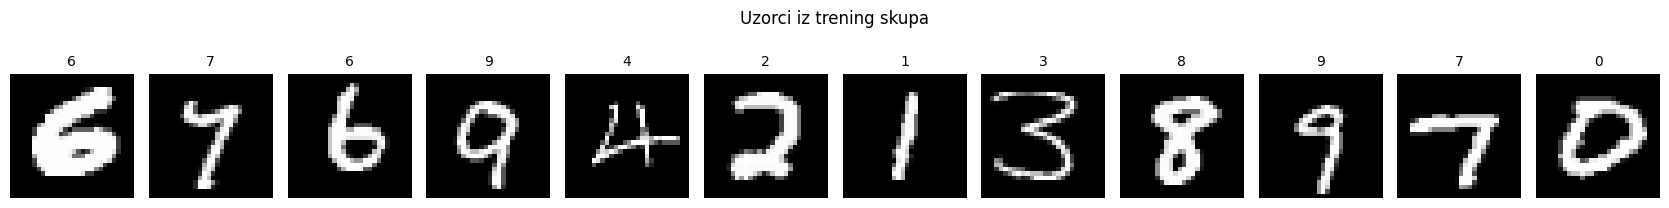

In [21]:
fig = plot_sample_images(train_set, n=12)
plt.show()

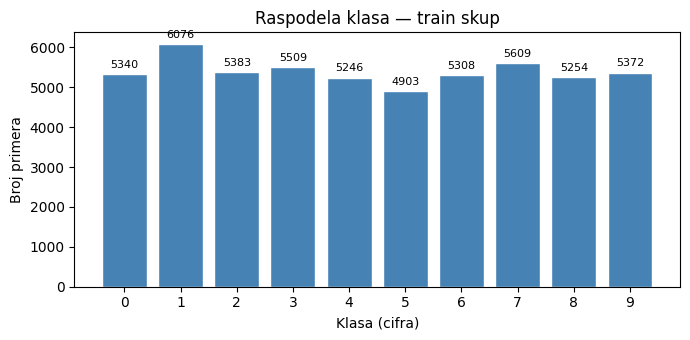

In [22]:
fig = plot_class_distribution(train_set, title="Raspodela klasa — train skup")
plt.show()

# MNIST je dobro balansiran (~6000 primera po klasi)
# Kod neuravnoteženih datasetova ovde bi se videla razlika koja utiče na izbor metrike

---
## 2. Baseline

Pre treniranja bilo kakvog modela, treba znati **referentnu tačku**.  
Baseline odgovara na pitanje: koliko bismo postigli sa trivijalnom strategijom?

Ovde koristimo **majority class** — uvek predvidi najčešću klasu.  
Ako trenirani model ne pobedi ovaj baseline, nešto je fundamentalno pogrešno.

In [23]:
baseline_acc = majority_class_accuracy(train_set)
print(f"Majority class baseline accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print()
print("MNIST je skoro savršeno balansiran — svaka klasa ima ~10% primera.")
print("Trivijalni model postiže ~10%. Cilj treninga je značajno iznad toga.")

Majority class baseline accuracy: 0.1125 (11.25%)

MNIST je skoro savršeno balansiran — svaka klasa ima ~10% primera.
Trivijalni model postiže ~10%. Cilj treninga je značajno iznad toga.


---
## 3. MLP — bez regularizacije

Počinjemo sa **MLP-om bez dropout-a i weight decay-a**.  
Ideja: pokazati šta se dešava kada model ima dovoljno kapaciteta ali nema regularizaciju.

Arhitektura:  
`[784] → Linear(256) → ReLU → Linear(128) → ReLU → Linear(10)`

Ulaz je slika razvučena u vektor: 28×28 = **784** vrednosti.

In [24]:
mlp_noreg = MLP(hidden_dims=cfg.hidden_dims, dropout=0.0).to(device)
print(f"MLP bez regularizacije — broj parametara: {count_parameters(mlp_noreg):,}")
print()
print(mlp_noreg)

MLP bez regularizacije — broj parametara: 235,146

MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [25]:
# Jedan forward pass da proverimo dimenzije pre treninga
with torch.no_grad():
    logits_test = mlp_noreg(x_batch.to(device))
print(f"Oblik logits-a: {logits_test.shape}  — [B, num_classes]")
print("Logits su sirovi skorovi — nisu verovatnoće.")
print("CrossEntropyLoss interno primenjuje log-softmax pa prima logits, ne softmax(logits).")

Oblik logits-a: torch.Size([64, 10])  — [B, num_classes]
Logits su sirovi skorovi — nisu verovatnoće.
CrossEntropyLoss interno primenjuje log-softmax pa prima logits, ne softmax(logits).


In [26]:
from dataclasses import replace
cfg_noreg = replace(cfg, weight_decay=0.0)

t0 = time.time()
history_mlp_noreg = fit(
    mlp_noreg, train_loader, val_loader,
    cfg_noreg, device, label="mlp_noreg"
)
time_mlp_noreg = time.time() - t0

print(f"\nUkupno vreme treninga (MLP bez reg.): {time_mlp_noreg:.1f}s")

results["MLP bez reg."] = {
    "history": history_mlp_noreg,
    "time_s": time_mlp_noreg,
    "params": count_parameters(mlp_noreg),
    "model": mlp_noreg,
    "label": "mlp_noreg",
}

# Colab: preuzmi checkpoint odmah — ne čekaj kraj svih treninga
colab_save("mlp_noreg")

[mlp_noreg] Epoha  1/15 | train loss=0.2433 acc=0.9271 | val loss=0.1330 acc=0.9595
[mlp_noreg] Epoha  2/15 | train loss=0.0947 acc=0.9701 | val loss=0.1011 acc=0.9693
[mlp_noreg] Epoha  3/15 | train loss=0.0662 acc=0.9789 | val loss=0.0974 acc=0.9735
[mlp_noreg] Epoha  4/15 | train loss=0.0517 acc=0.9831 | val loss=0.0930 acc=0.9742
[mlp_noreg] Epoha  5/15 | train loss=0.0407 acc=0.9865 | val loss=0.0982 acc=0.9727
[mlp_noreg] Epoha  6/15 | train loss=0.0331 acc=0.9891 | val loss=0.0953 acc=0.9752
[mlp_noreg] Epoha  7/15 | train loss=0.0281 acc=0.9906 | val loss=0.0967 acc=0.9755
[mlp_noreg] Epoha  8/15 | train loss=0.0258 acc=0.9912 | val loss=0.0814 acc=0.9777
[mlp_noreg] Epoha  9/15 | train loss=0.0226 acc=0.9930 | val loss=0.1199 acc=0.9720
[mlp_noreg] Epoha 10/15 | train loss=0.0188 acc=0.9933 | val loss=0.0997 acc=0.9765
[mlp_noreg] Epoha 11/15 | train loss=0.0208 acc=0.9931 | val loss=0.0904 acc=0.9803
[mlp_noreg] Epoha 12/15 | train loss=0.0154 acc=0.9951 | val loss=0.1070 acc

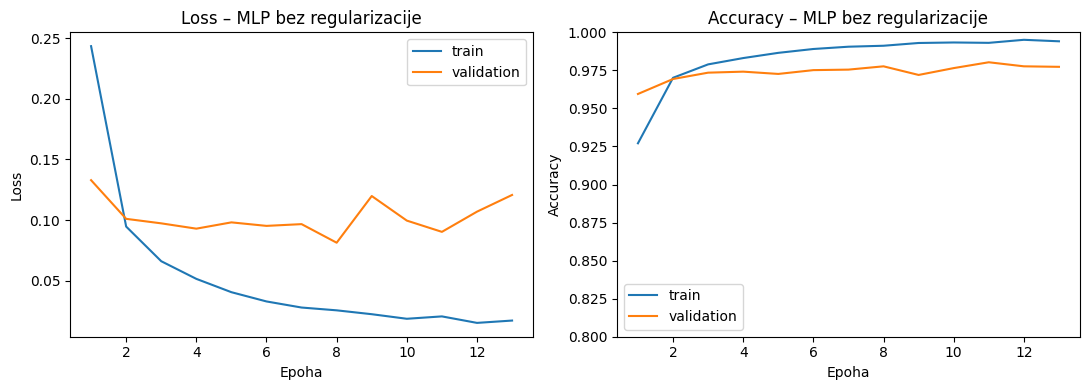


Ako train loss opada brže od val loss-a i val loss počne da raste — overfitting.
Na MNIST-u to nije dramatično, ali uzorak je vidljiv.


In [27]:
fig = plot_loss_curves(history_mlp_noreg, title="MLP bez regularizacije")
plt.show()

print()
print("Ako train loss opada brže od val loss-a i val loss počne da raste — overfitting.")
print("Na MNIST-u to nije dramatično, ali uzorak je vidljiv.")

Predikcije MLP (bez reg.) na nasumičnim primerima iz val skupa:


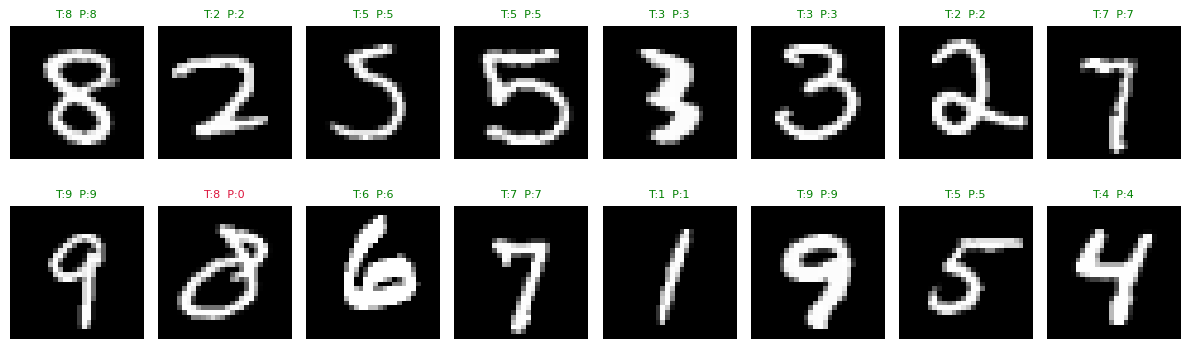

In [28]:
print("Predikcije MLP (bez reg.) na nasumičnim primerima iz val skupa:")
fig = plot_predictions(mlp_noreg, val_set, device, n=16)
plt.show()

---
## 4. MLP — sa regularizacijom

Isti MLP, ali sa:
- **Dropout(0.3)** — nasumično deaktivira 30% neurona tokom treninga
- **Weight decay (L2) = 1e-4** — kažnjava prevelike vrednosti težina

Regularizacija pomaže modelu da generalizuje — uči obrasce, ne memoriše primere.

In [29]:
mlp_reg = MLP(hidden_dims=cfg.hidden_dims, dropout=cfg.dropout).to(device)
print(f"MLP sa regularizacijom — broj parametara: {count_parameters(mlp_reg):,}")
print(f"Dropout stopa: {cfg.dropout}")
print(f"Weight decay:  {cfg.weight_decay}")

MLP sa regularizacijom — broj parametara: 235,146
Dropout stopa: 0.3
Weight decay:  0.0001


In [30]:
t0 = time.time()
history_mlp_reg = fit(
    mlp_reg, train_loader, val_loader,
    cfg, device, label="mlp_reg"
)
time_mlp_reg = time.time() - t0

print(f"\nUkupno vreme treninga (MLP sa reg.): {time_mlp_reg:.1f}s")

results["MLP + reg."] = {
    "history": history_mlp_reg,
    "time_s": time_mlp_reg,
    "params": count_parameters(mlp_reg),
    "model": mlp_reg,
    "label": "mlp_reg",
}

colab_save("mlp_reg")

[mlp_reg] Epoha  1/15 | train loss=0.3264 acc=0.8988 | val loss=0.1485 acc=0.9552
[mlp_reg] Epoha  2/15 | train loss=0.1596 acc=0.9517 | val loss=0.1238 acc=0.9637
[mlp_reg] Epoha  3/15 | train loss=0.1298 acc=0.9620 | val loss=0.1140 acc=0.9660
[mlp_reg] Epoha  4/15 | train loss=0.1119 acc=0.9651 | val loss=0.0921 acc=0.9747
[mlp_reg] Epoha  5/15 | train loss=0.0991 acc=0.9695 | val loss=0.0806 acc=0.9752
[mlp_reg] Epoha  6/15 | train loss=0.0951 acc=0.9711 | val loss=0.0927 acc=0.9737
[mlp_reg] Epoha  7/15 | train loss=0.0855 acc=0.9733 | val loss=0.0898 acc=0.9733
[mlp_reg] Epoha  8/15 | train loss=0.0832 acc=0.9744 | val loss=0.0885 acc=0.9770
[mlp_reg] Epoha  9/15 | train loss=0.0766 acc=0.9759 | val loss=0.0907 acc=0.9762
[mlp_reg] Epoha 10/15 | train loss=0.0737 acc=0.9775 | val loss=0.0799 acc=0.9795
[mlp_reg] Epoha 11/15 | train loss=0.0731 acc=0.9770 | val loss=0.0800 acc=0.9785
[mlp_reg] Epoha 12/15 | train loss=0.0681 acc=0.9782 | val loss=0.0870 acc=0.9762
[mlp_reg] Epoha 

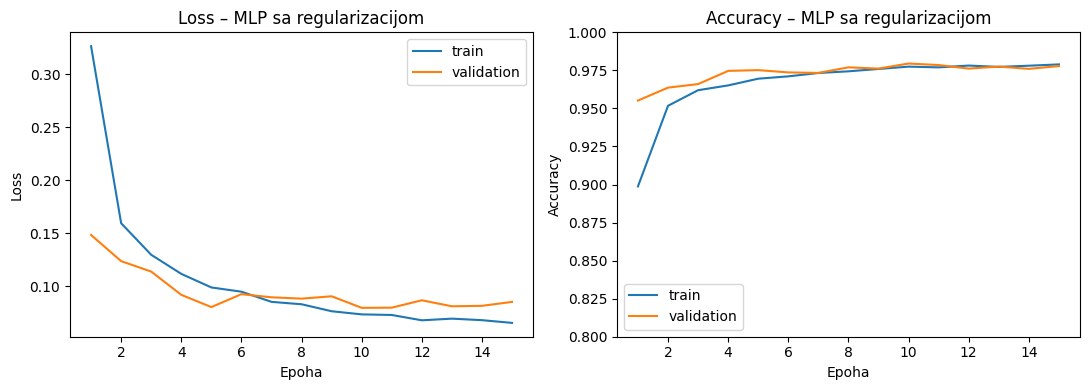

In [31]:
fig = plot_loss_curves(history_mlp_reg, title="MLP sa regularizacijom")
plt.show()

Predikcije MLP (sa reg.) na nasumičnim primerima iz val skupa:


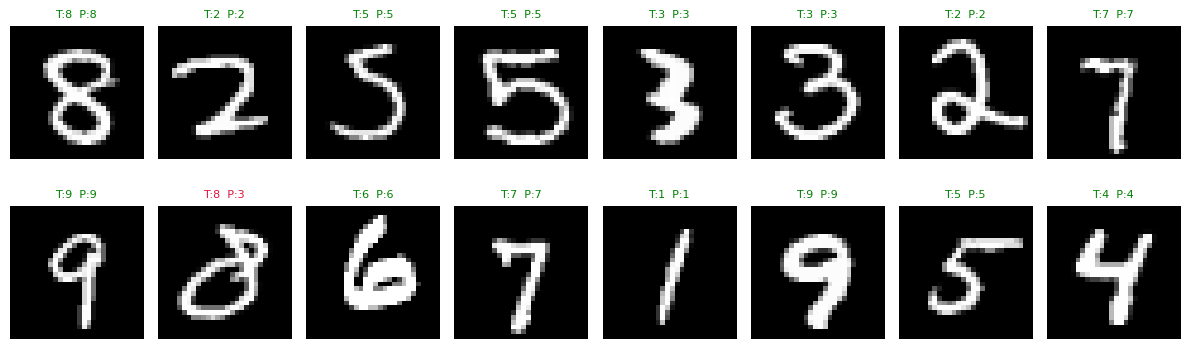

In [32]:
print("Predikcije MLP (sa reg.) na nasumičnim primerima iz val skupa:")
fig = plot_predictions(mlp_reg, val_set, device, n=16)
plt.show()

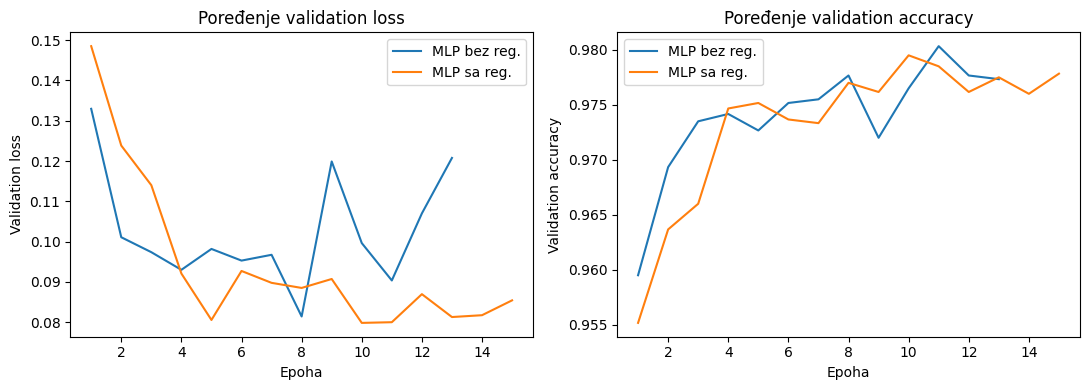


Regularizovani model tipično ima manji jaz između train i val krive.


In [33]:
fig = compare_loss_curves({
    "MLP bez reg.": history_mlp_noreg,
    "MLP sa reg.": history_mlp_reg,
})
plt.show()

print()
print("Regularizovani model tipično ima manji jaz između train i val krive.")

---
## 5. CNN — konvoluciona mreža

MLP razvlači sliku u vektor i gubi prostornu strukturu.  
**CNN** obrađuje sliku direktno konvolucionim filterima koji uče lokalne obrasce (ivice, uglovi, teksture).

Arhitektura:
```
Conv(1→32) → ReLU → Conv(32→32) → ReLU → MaxPool(2) → Dropout2d  [28→14]
Conv(32→64) → ReLU → Conv(64→64) → ReLU → MaxPool(2) → Dropout2d  [14→7]
Flatten → Linear(64*7*7 → 128) → ReLU → Dropout → Linear(128→10)
```

> Konvolucioni filteri dele težine po prostoru (weight sharing) — efikasniji su od MLP-a
> za slike jer ne uče zasebne težine za svaku poziciju piksela.

In [34]:
cnn = CNN(channels=cfg.cnn_channels, dropout=cfg.cnn_dropout).to(device)
print(f"CNN — broj parametara: {count_parameters(cnn):,}")
print()
print(cnn)

CNN — broj parametara: 467,818

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Dropout2d(p=0.25, inplace=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout2d(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [35]:
t0 = time.time()
history_cnn = fit(
    cnn, train_loader, val_loader,
    cfg, device, label="cnn"
)
time_cnn = time.time() - t0

print(f"\nUkupno vreme treninga (CNN): {time_cnn:.1f}s")

results["CNN"] = {
    "history": history_cnn,
    "time_s": time_cnn,
    "params": count_parameters(cnn),
    "model": cnn,
    "label": "cnn",
}

colab_save("cnn")

[cnn] Epoha  1/15 | train loss=0.1882 acc=0.9428 | val loss=0.0615 acc=0.9825
[cnn] Epoha  2/15 | train loss=0.0701 acc=0.9790 | val loss=0.0482 acc=0.9853
[cnn] Epoha  3/15 | train loss=0.0526 acc=0.9838 | val loss=0.0448 acc=0.9878
[cnn] Epoha  4/15 | train loss=0.0445 acc=0.9866 | val loss=0.0394 acc=0.9883
[cnn] Epoha  5/15 | train loss=0.0375 acc=0.9884 | val loss=0.0321 acc=0.9910
[cnn] Epoha  6/15 | train loss=0.0345 acc=0.9889 | val loss=0.0295 acc=0.9918
[cnn] Epoha  7/15 | train loss=0.0336 acc=0.9899 | val loss=0.0301 acc=0.9918
[cnn] Epoha  8/15 | train loss=0.0310 acc=0.9906 | val loss=0.0390 acc=0.9907
[cnn] Epoha  9/15 | train loss=0.0298 acc=0.9907 | val loss=0.0328 acc=0.9907
[cnn] Epoha 10/15 | train loss=0.0270 acc=0.9921 | val loss=0.0367 acc=0.9903
[cnn] Epoha 11/15 | train loss=0.0239 acc=0.9930 | val loss=0.0403 acc=0.9888
  Early stopping — nema poboljšanja 5 epoha.

Ukupno vreme treninga (CNN): 282.8s


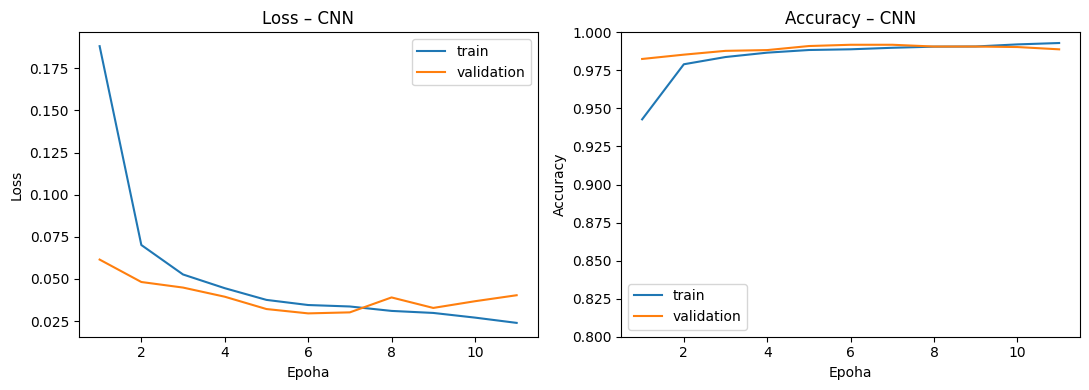

In [36]:
fig = plot_loss_curves(history_cnn, title="CNN")
plt.show()

Predikcije CNN na nasumičnim primerima iz val skupa:


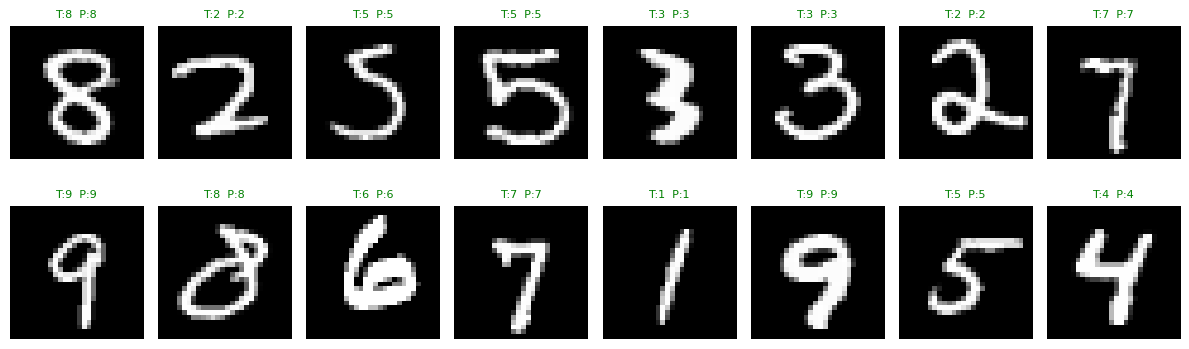

In [37]:
print("Predikcije CNN na nasumičnim primerima iz val skupa:")
fig = plot_predictions(cnn, val_set, device, n=16)
plt.show()

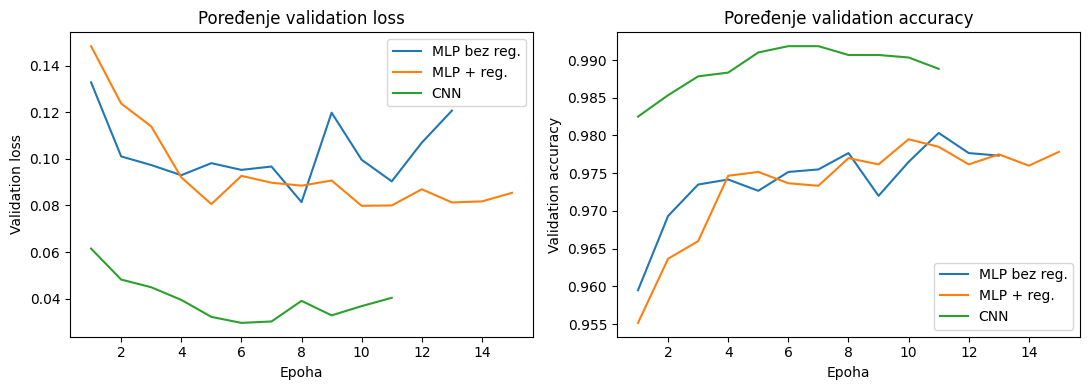

In [38]:
fig = compare_loss_curves({
    "MLP bez reg.": history_mlp_noreg,
    "MLP + reg.": history_mlp_reg,
    "CNN": history_cnn,
})
plt.show()

---
## 6. Checkpointing

Tokom treninga, `fit()` je automatski čuvao dva tipa checkpointa posle svake epohe:

- `best_<model>.pth` — state sa **najboljim val loss-om** (ovo koristimo za evaluaciju)
- `last_<model>.pth` — poslednje stanje treninga (korisno za nastavak ako trening pukne)

Za veće modele i duži trening možeš uključiti `cfg.save_all_epochs = True` —  
tada se čuva i `<model>_epoch_NN.pth` za svaku epohu, pa možeš da se vratiš na bilo koju.

Checkpoint sadrži: `epoch`, `model_state`, `optimizer_state`, `val_loss`, `config`.

In [39]:
checkpoints = sorted(os.listdir(cfg.checkpoint_dir))
print("Sačuvani checkpointi:")
for f in checkpoints:
    path = os.path.join(cfg.checkpoint_dir, f)
    size_kb = os.path.getsize(path) / 1024
    print(f"  {f:<35} {size_kb:.1f} KB")

Sačuvani checkpointi:
  best_cnn.pth                        5497.6 KB
  best_mlp_noreg.pth                  2763.9 KB
  best_mlp_reg.pth                    2763.9 KB
  last_cnn.pth                        5497.6 KB
  last_mlp_noreg.pth                  2763.9 KB
  last_mlp_reg.pth                    2763.9 KB
  mlp_noreg_vis                       4.0 KB


In [40]:
# Učitavamo NOVU instancu modela i punjemo je iz checkpointa
# To je čist test da učitavanje zaista funkcioniše

best_cnn = CNN(channels=cfg.cnn_channels, dropout=cfg.cnn_dropout).to(device)
ckpt = load_checkpoint(os.path.join(cfg.checkpoint_dir, "best_cnn.pth"), best_cnn)

print(f"Učitan checkpoint: epoha {ckpt['epoch']}, val loss = {ckpt['val_loss']:.4f}")

Učitan checkpoint: epoha 6, val loss = 0.0295


---
## 7. Evaluacija na test skupu

**Test skup koristimo samo jednom** — na kraju, nakon što smo:
- izabrali arhitekturu (CNN),
- odredili hiperparametre (lr, dropout, weight_decay),
- izabrali model (best checkpoint prema val loss-u).

Ako bismo koristili test skup za bilo šta od navedenog, on bi prestao da bude objektivan.

In [41]:
y_pred, y_true, images = get_predictions(best_cnn, test_loader, device)

test_acc = (y_pred == y_true).mean()
print(f"Test accuracy (CNN, best checkpoint): {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Baseline (majority class):            {majority_class_accuracy(test_set):.4f}")
print(f"Poboljšanje nad baseline-om:          +{(test_acc - majority_class_accuracy(test_set))*100:.1f} pp")

Test accuracy (CNN, best checkpoint): 0.9939 (99.39%)
Baseline (majority class):            0.1135
Poboljšanje nad baseline-om:          +88.0 pp


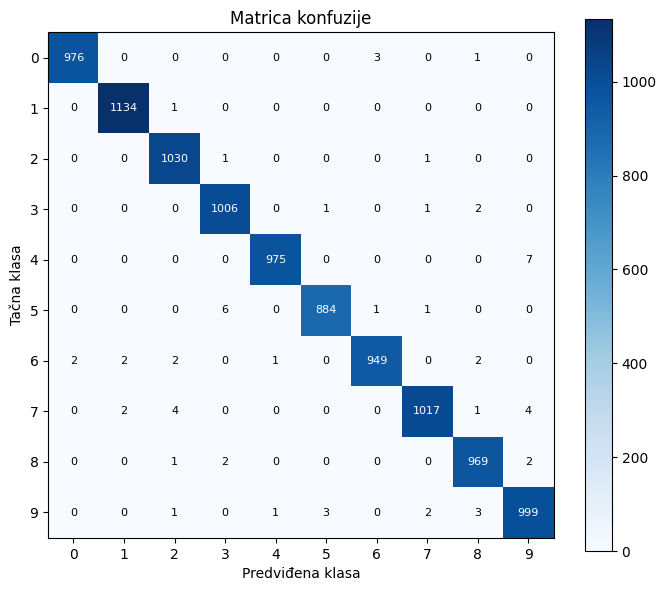


Dijagonala = tačne predikcije.
Van dijagonale = greške. Koja dva broja se model najčešće meša?


In [42]:
fig = plot_confusion_matrix(y_true, y_pred)
plt.show()

print()
print("Dijagonala = tačne predikcije.")
print("Van dijagonale = greške. Koja dva broja se model najčešće meša?")

In [43]:
print("Izveštaj po klasama:")
print_classification_report(y_true, y_pred)

Izveštaj po klasama:
              precision    recall  f1-score   support

           0     0.9980    0.9959    0.9969       980
           1     0.9965    0.9991    0.9978      1135
           2     0.9913    0.9981    0.9947      1032
           3     0.9911    0.9960    0.9936      1010
           4     0.9980    0.9929    0.9954       982
           5     0.9955    0.9910    0.9933       892
           6     0.9958    0.9906    0.9932       958
           7     0.9951    0.9893    0.9922      1028
           8     0.9908    0.9949    0.9928       974
           9     0.9872    0.9901    0.9886      1009

    accuracy                         0.9939     10000
   macro avg     0.9939    0.9938    0.9939     10000
weighted avg     0.9939    0.9939    0.9939     10000



### Kako čitati ovaj izveštaj

| Metrika | Šta meri |
| --- | --- |
| **precision** | Od svih koje je model predvideo kao klasu X, koliko je stvarno X? |
| **recall** | Od svih stvarnih X, koliko je model prepoznao? |
| **f1-score** | Harmonijska sredina precision i recall |
| **support** | Broj primera te klase u test skupu |

Na balansiranom datasetu poput MNIST-a, sve klase imaju sličan support i accuracy je dobra metrika.  
Na neuravnoteženom datasetu, accuracy može biti varljiva — tu F1 i confusion matrix daju bolji uvid.

---
## 8. Analiza grešaka

Finalna metrika govori **koliko** model greši. Analiza grešaka govori **gde** i **zašto**.

Pregledom konkretnih pogrešnih primera možemo otkriti:
- da li se greške javljaju na lošoj kvalitetu slike (šum, rotacija, zamagljenost),
- da li model meša vizuelno slične cifre (npr. 4/9, 3/8, 1/7),
- da li postoje pogrešne labele u datasetu.

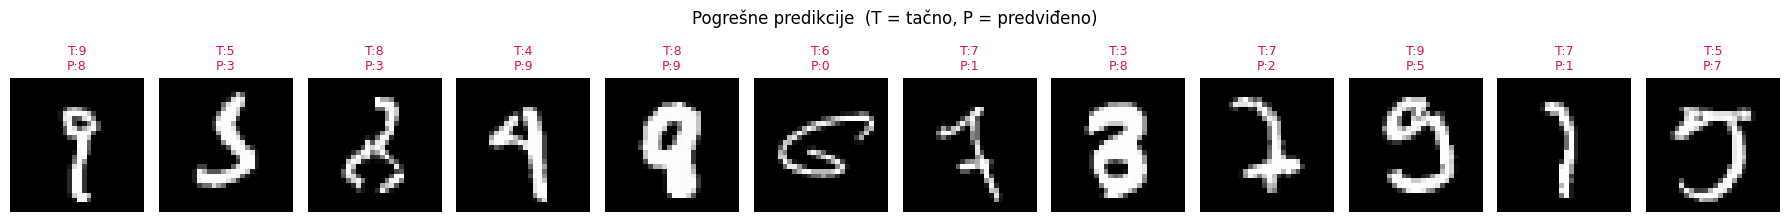

In [44]:
fig = plot_errors(images, y_true, y_pred, n=12)
plt.show()

In [45]:
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
np.fill_diagonal(cm, 0)

top_k = 5
flat_idx = np.argsort(cm.flatten())[::-1][:top_k]
print(f"Top {top_k} najčešćih konfuzija (tačno → predviđeno):")
for idx in flat_idx:
    true_cls = idx // cm.shape[1]
    pred_cls = idx % cm.shape[1]
    print(f"  {true_cls} → {pred_cls}: {cm[true_cls, pred_cls]} puta")

Top 5 najčešćih konfuzija (tačno → predviđeno):
  4 → 9: 7 puta
  5 → 3: 6 puta
  7 → 9: 4 puta
  7 → 2: 4 puta
  9 → 8: 3 puta


---
## 9. Finalno poređenje sva tri modela

Sad kad smo istrenirali sva tri modela, možemo ih uporediti objektivno:
- **Test accuracy** — koliko dobro generalizuju na podatke koje nisu videli
- **Vreme treninga** — koliko je koštao eksperiment
- **Broj parametara** — koliko je model "velik"

Za test accuracy koristimo **best checkpoint** svakog modela (sačuvan prema val loss-u).

In [46]:
model_constructors = {
    "MLP bez reg.": lambda: MLP(hidden_dims=cfg.hidden_dims, dropout=0.0).to(device),
    "MLP + reg.":   lambda: MLP(hidden_dims=cfg.hidden_dims, dropout=cfg.dropout).to(device),
    "CNN":          lambda: CNN(channels=cfg.cnn_channels, dropout=cfg.cnn_dropout).to(device),
}

for name, constructor in model_constructors.items():
    label = results[name]["label"]
    ckpt_path = os.path.join(cfg.checkpoint_dir, f"best_{label}.pth")
    m = constructor()
    load_checkpoint(ckpt_path, m)
    preds, trues, _ = get_predictions(m, test_loader, device)
    results[name]["test_acc"] = (preds == trues).mean()

print(f"{'Model':<18} {'Params':>10} {'Vreme':>10} {'Test acc':>12}")
print("-" * 54)
for name, r in results.items():
    print(f"{name:<18} {r['params']:>9,}  {r['time_s']:>8.1f}s  {r['test_acc']*100:>10.2f}%")

Model                  Params      Vreme     Test acc
------------------------------------------------------
MLP bez reg.         235,146     253.2s       97.84%
MLP + reg.           235,146     300.2s       98.13%
CNN                  467,818     282.8s       99.39%


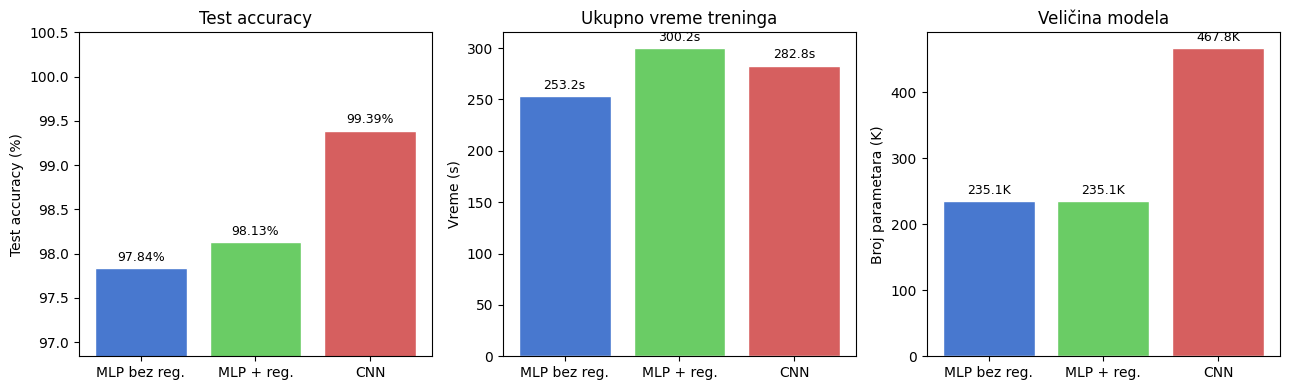

In [47]:
fig = plot_model_comparison(results)
plt.show()

In [48]:
best_name = max(results, key=lambda n: results[n]["test_acc"])
best_r = results[best_name]

print(f"Najbolji model po test accuracy: {best_name}")
print(f"  Test accuracy: {best_r['test_acc']*100:.2f}%")
print(f"  Vreme treninga: {best_r['time_s']:.1f}s")
print(f"  Broj parametara: {best_r['params']:,}")
print()
print("Napomena: više parametara i duži trening ne garantuju bolji model.")
print("CNN ima induktivnu prednost (prostorna struktura) — zato uzima manje da nauči.")

Najbolji model po test accuracy: CNN
  Test accuracy: 99.39%
  Vreme treninga: 282.8s
  Broj parametara: 467,818

Napomena: više parametara i duži trening ne garantuju bolji model.
CNN ima induktivnu prednost (prostorna struktura) — zato uzima manje da nauči.


Predikcije CNN (best checkpoint) na nasumičnim primerima iz val skupa:


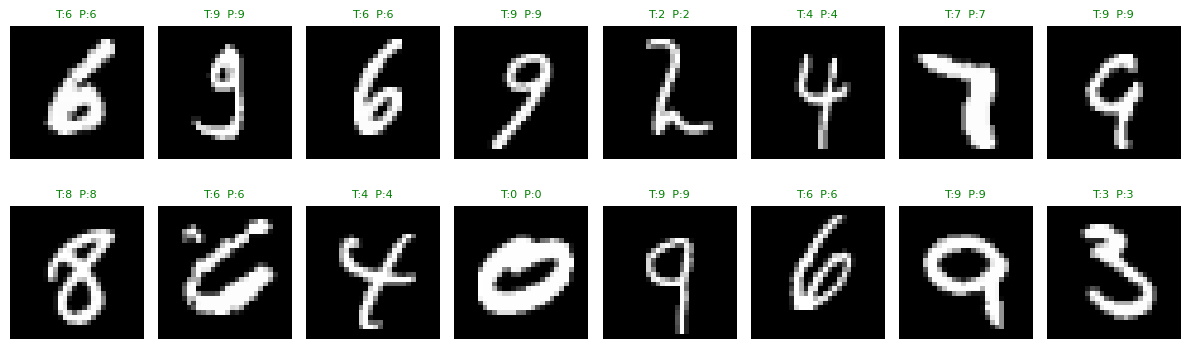

In [49]:
best_model_obj = model_constructors[best_name]()
load_checkpoint(
    os.path.join(cfg.checkpoint_dir, f"best_{results[best_name]['label']}.pth"),
    best_model_obj
)
print(f"Predikcije {best_name} (best checkpoint) na nasumičnim primerima iz val skupa:")
fig = plot_predictions(best_model_obj, val_set, device, n=16, seed=7)
plt.show()

---
## Zaključak

Ovaj notebook je prošao celokupan ML eksperiment:

| Korak | Šta smo radili |
| --- | --- |
| **Dataset** | Učitali MNIST, podelili train/val/test, vizualizovali raspodelu klasa |
| **Baseline** | Izračunali tačnost trivijalne strategije |
| **MLP bez reg.** | Trenirali model i pokazali potencijal za overfitting |
| **MLP + reg.** | Isti model sa dropout + weight decay |
| **CNN** | Konvoluciona mreža bolja za prostorne podatke |
| **Checkpointing** | Sačuvali i učitali best checkpoint |
| **Test evaluacija** | Accuracy, matrica konfuzije, per-class report |
| **Analiza grešaka** | Konkretne greške — šta model meša i zašto |
| **Poređenje** | Accuracy, vreme treninga i veličina sva tri modela |

---

**Za vaš projekat:**  
Zadržite ovaj obrazac. Promenite:
- `load_mnist` → vaša funkcija za učitavanje podataka  
- `MLP` / `CNN` → vaša arhitektura  
- `CrossEntropyLoss` → loss koji odgovara vašem zadatku  
- `accuracy` → metrika koja ima smisla za vaš problem  

Ostatak pipeline-a ostaje isti.